In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

In [3]:
class PINN(nn.Module):

    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(1,50),
            nn.Tanh(),

            nn.Linear(50,50),
            nn.Tanh(),

            nn.Linear(50,50),
            nn.Tanh(),

            nn.Linear(50,1)
        )

    def forward(self,x):
        return self.net(x)

In [57]:
N = 100

sobol = torch.quasirandom.SobolEngine(dimension=1)
x = sobol.draw(N)

x = x.requires_grad_(True)

In [58]:
def compute_residual(model,x):

    u = model(x)

    du_dx = torch.autograd.grad(
        u, x,
        grad_outputs=torch.ones_like(u),
        create_graph=True
    )[0]

    d2u_dx2 = torch.autograd.grad(
        du_dx, x,
        grad_outputs=torch.ones_like(du_dx),
        create_graph=True
    )[0]

    f = -np.pi**2 * torch.sin(np.pi*x)

    residual = d2u_dx2 - f

    return residual

In [59]:
x_bc = torch.tensor([[0.0],[1.0]])
u_bc = torch.tensor([[0.0],[0.0]])

In [60]:
def boundary_loss(model):

    pred = model(x_bc)

    return torch.mean((pred-u_bc)**2)

In [61]:
def physics_loss(model,x):

    residual = compute_residual(model,x)

    return torch.mean(residual**2)

In [65]:
model = PINN()

optimizer = torch.optim.Adam(model.parameters(),lr=1e-3)

epochs = 10000

loss_history = []

for epoch in range(epochs):

    optimizer.zero_grad()

    p_loss = physics_loss(model,x)
    b_loss = boundary_loss(model)

    loss = p_loss + b_loss

    loss.backward()

    optimizer.step()

    loss_history.append(loss.item())

    if epoch%500==0:
        print(epoch,loss.item())

0 48.63276672363281
500 0.0018124938942492008
1000 0.0008163818274624646
1500 0.0001596108340891078
2000 7.970356091391295e-05
2500 6.269710866035894e-05
3000 6.827107426943257e-05
3500 3.943717456422746e-05
4000 3.615449895733036e-05
4500 2.5400986487511545e-05
5000 2.0053301341249608e-05
5500 1.5813155187061056e-05
6000 1.2414303455443587e-05
6500 1.1473581253085285e-05
7000 7.852938324504066e-06
7500 0.0005460288957692683
8000 6.039833897375502e-05
8500 0.00021424599981401116
9000 4.578902917273808e-06
9500 5.861986574018374e-05


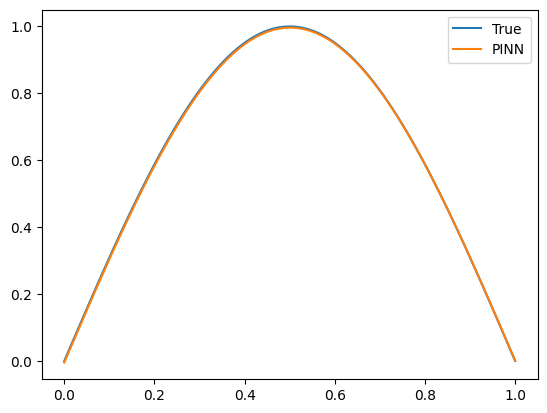

In [66]:
x_test = torch.linspace(0,1,100).view(-1,1)

with torch.no_grad():
    pred = model(x_test)

true = torch.sin(np.pi*x_test)

plt.plot(x_test,true,label="True")
plt.plot(x_test,pred,label="PINN")
plt.legend()
plt.show()

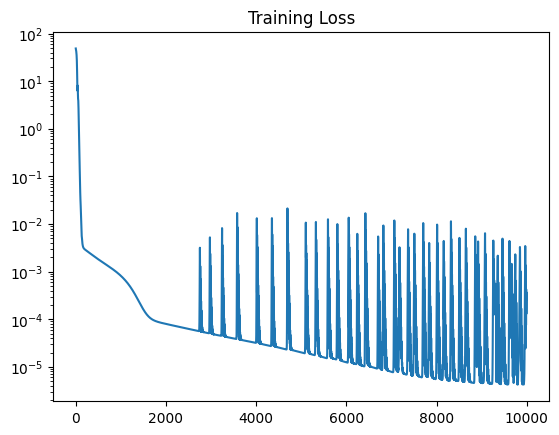

In [67]:
plt.plot(loss_history)
plt.yscale("log")
plt.title("Training Loss")
plt.show()